# TP : Apprentissage Supervisé - Classification (exercice)
## Dataset : Spambase (détection de spam, OpenML)

**Algorithmes couverts :**

| Algo | Famille | Caractéristique |
|---|---|---|
| Régression Logistique | Linéaire | Rapide, interprétable |
| KNN | Instance-based | Simple, sensible à l'échelle |
| Decision Tree | Arbre | Interprétable, sujet à l'overfitting |
| Random Forest | Ensemble (bagging) | Robuste, peu de réglage |
| XGBoost | Ensemble (boosting) | Souvent le plus performant |

**Datamap (dictionnaire des données) :** 57 mesures extraites du texte de chaque email, regroupées en 3 familles.

| Famille de colonnes | Nombre | Description |
|---|---|---|
| `word_freq_*` | 48 | % d'occurrences d'un mot donné dans l'email (ex : `word_freq_free`, `word_freq_money`) |
| `char_freq_*` | 6 | % d'occurrences d'un caractère donné (`;`, `(`, `[`, `!`, `$`, `#`) |
| `capital_run_length_*` | 3 | Longueur des séquences de lettres majuscules (moyenne, la plus longue, totale) |

**Cible :** `class` : 0 = non-spam, 1 = spam.

> **Version exercice** : les cellules marquées `# TODO` sont à compléter. Le reste (imports, chargement des données, affichages) est déjà fourni.
> Installe les dépendances une seule fois avec `pip install -r requirements.txt` depuis `cours_ml/todo/` (voir le README de ce dossier). Ce TP s'inspire de `cours_ml/02_supervise/tp_classification.ipynb` (même méthode, données différentes et plus volumineuses : 4601 emails contre 569 tumeurs).

---
## 0. Imports & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


---
## 1. Chargement & exploration

In [2]:
# Spambase : 4601 emails, 57 mesures (frequences de mots/caracteres, longueurs de sequences en majuscules)
# Chargement depuis OpenML (dataset public, aucune authentification requise)
spam = fetch_openml(name='spambase', version='active', as_frame=True, parser='auto')
df_raw = spam.frame.drop(columns=['class']).astype(float)
y = spam.frame['class'].astype(int).values
X = df_raw.values
feature_names = list(df_raw.columns)
class_names = ['non-spam', 'spam']

print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
df_raw.head()


Dimensions : 4601 lignes x 57 colonnes


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0


In [3]:
df_raw.describe().round(2)

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
count,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00,4601.00
mean,0.10,0.21,0.28,0.07,0.31,0.10,0.11,0.11,0.09,0.24,0.06,0.54,0.09,0.06,0.05,0.25,0.14,0.18,1.66,0.09,0.81,0.12,0.10,0.09,0.55,0.27,0.77,0.12,0.10,0.10,0.06,0.05,0.10,0.05,0.11,0.10,0.14,0.01,0.08,0.06,0.04,0.13,0.05,0.08,0.30,0.18,0.01,0.03,0.04,0.14,0.02,0.27,0.08,0.04,5.19,52.17,283.29
std,0.31,1.29,0.50,1.40,0.67,0.27,0.39,0.40,0.28,0.64,0.20,0.86,0.30,0.34,0.26,0.83,0.44,0.53,1.78,0.51,1.20,1.03,0.35,0.44,1.67,0.89,3.37,0.54,0.59,0.46,0.40,0.33,0.56,0.33,0.53,0.40,0.42,0.22,0.43,0.35,0.36,0.77,0.22,0.62,1.01,0.91,0.08,0.29,0.24,0.27,0.11,0.82,0.25,0.43,31.73,194.89,606.35
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.59,6.00,35.00
50%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.10,0.00,0.00,0.00,0.00,0.00,0.00,1.31,0.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,2.28,15.00,95.00
75%,0.00,0.00,0.42,0.00,0.38,0.00,0.00,0.00,0.00,0.16,0.00,0.80,0.00,0.00,0.00,0.10,0.00,0.00,2.64,0.00,1.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.00,0.00,0.00,0.19,0.00,0.32,0.05,0.00,3.71,43.00,266.00
max,4.54,14.28,5.10,42.81,10.00,5.88,7.27,11.11,5.26,18.18,2.61,9.67,5.55,10.00,4.41,20.00,7.14,9.09,18.75,18.18,11.11,17.10,5.45,12.50,20.83,16.66,33.33,9.09,14.28,5.88,12.50,4.76,18.18,4.76,20.00,7.69,6.89,8.33,11.11,4.76,7.14,14.28,3.57,20.00,21.42,22.05,2.17,10.00,4.38,9.75,4.08,32.48,6.00,19.83,1102.50,9989.00,15841.00


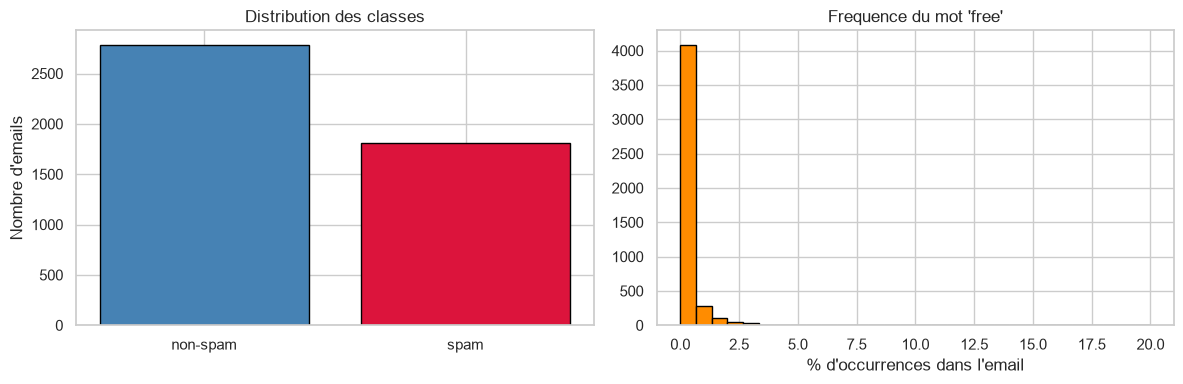

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, np.bincount(y), color=['steelblue', 'crimson'], edgecolor='k')
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'emails')

axes[1].hist(df_raw['word_freq_free'], bins=30, color='darkorange', edgecolor='k')
axes[1].set_title("Frequence du mot 'free'")
axes[1].set_xlabel('% d\'occurrences dans l\'email')

plt.tight_layout()
plt.show()


---
## 2. Prétraitement & split

In [5]:
# TODO : separer train/test (80/20, stratifie sur y) puis normaliser avec StandardScaler
# Indice : train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train : {X_train.shape[0]} échantillons | Test : {X_test.shape[0]} échantillons")
print(f"Train classes : {dict(zip(class_names, np.bincount(y_train)))}")
print(f"Test  classes : {dict(zip(class_names, np.bincount(y_test)))}")

# Normalisation (intégrée dans les pipelines ci-dessous)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Train : 3680 échantillons | Test : 921 échantillons
Train classes : {'non-spam': np.int64(2230), 'spam': np.int64(1450)}
Test  classes : {'non-spam': np.int64(558), 'spam': np.int64(363)}


---
## 3. Régression Logistique

Modèle linéaire qui prédit la **probabilité** d'appartenir à une classe via la fonction sigmoïde.

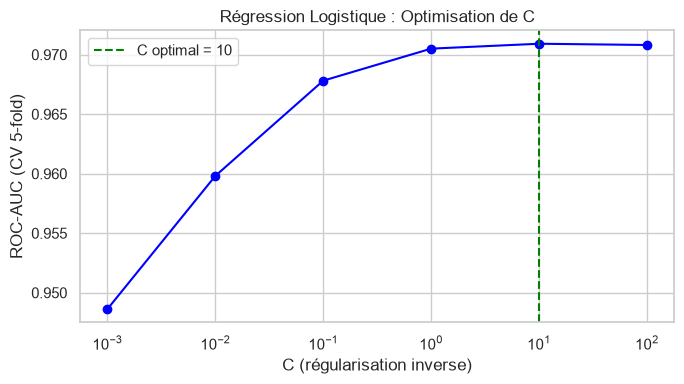

C optimal : 10 | ROC-AUC CV : 0.9709


In [8]:
# Optimisation : recherche du meilleur C par cross-validation
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
cv_scores_lr = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for C in C_values:
    # TODO : construire un Pipeline(StandardScaler + LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))
    # puis mesurer son ROC-AUC en cross-validation (cross_val_score(..., cv=cv, scoring='roc_auc'))
    pipe = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_lr.append(scores.mean())

best_C = C_values[np.argmax(cv_scores_lr)]

plt.figure(figsize=(7, 4))
plt.semilogx(C_values, cv_scores_lr, 'bo-')
plt.axvline(best_C, color='green', linestyle='--', label=f'C optimal = {best_C}')
plt.xlabel('C (régularisation inverse)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('Régression Logistique : Optimisation de C')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer le pipeline final avec C=best_C sur (X_train, y_train)
pipe_lr = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(C=best_C, max_iter=1000, random_state=RANDOM_STATE))])
pipe_lr.fit(X_train, y_train)
print(f"C optimal : {best_C} | ROC-AUC CV : {max(cv_scores_lr):.4f}")


---
## 4. KNN

Prédit la classe d'un point en regardant les **k voisins les plus proches**. Sensible à l'échelle → normalisation obligatoire.

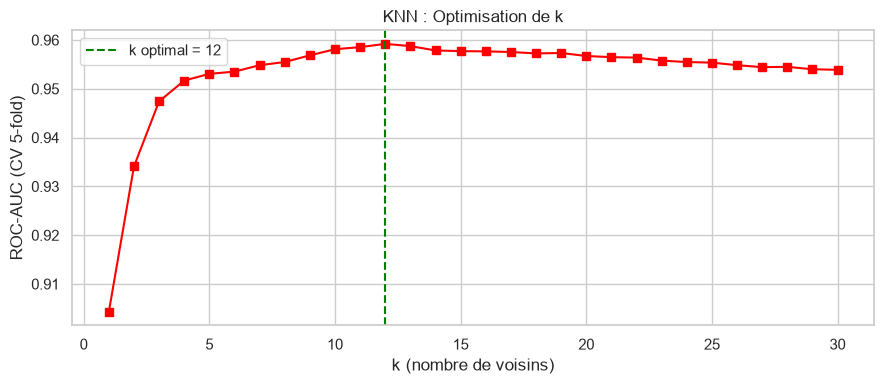

k optimal : 12 | ROC-AUC CV : 0.9592


In [11]:
k_values = range(1, 31)
cv_scores_knn = []

for k in k_values:
    # TODO : construire un Pipeline(StandardScaler + KNeighborsClassifier(n_neighbors=k)) et mesurer son ROC-AUC en CV
    pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_scores_knn.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_scores_knn)]

plt.figure(figsize=(9, 4))
plt.plot(k_values, cv_scores_knn, 'rs-')
plt.axvline(best_k, color='green', linestyle='--', label=f'k optimal = {best_k}')
plt.xlabel('k (nombre de voisins)')
plt.ylabel('ROC-AUC (CV 5-fold)')
plt.title('KNN : Optimisation de k')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer le pipeline final avec n_neighbors=best_k sur (X_train, y_train)
pipe_knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))])
pipe_knn.fit(X_train, y_train)
print(f"k optimal : {best_k} | ROC-AUC CV : {max(cv_scores_knn):.4f}")


---
## 5. Decision Tree

Partitionne récursivement l'espace des features selon des seuils. Très interprétable mais tend à overfitter : régularisé via `max_depth`.

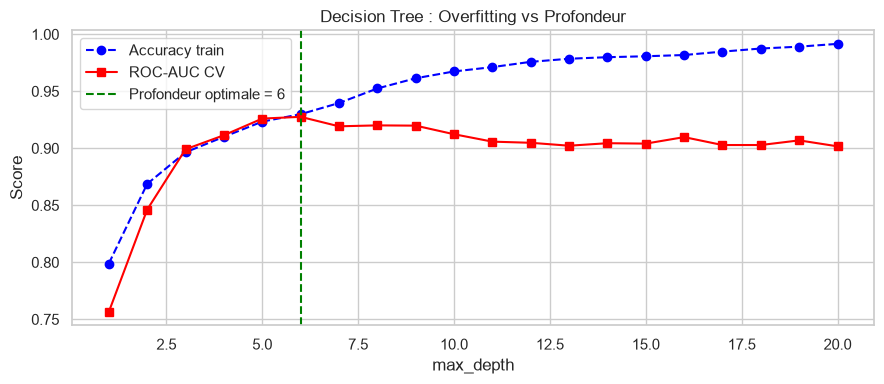

Profondeur optimale : 6 | ROC-AUC CV : 0.9276


In [12]:
depth_values = range(1, 21)
cv_scores_dt_train = []
cv_scores_dt = []

for d in depth_values:
    # TODO : entrainer un DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE) sur (X_train_sc, y_train)
    # puis stocker l'accuracy sur le train ET le ROC-AUC en cross-validation
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train_sc, y_train)
    cv_scores_dt_train.append(accuracy_score(y_train, dt.predict(X_train_sc)))
    scores = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc')
    cv_scores_dt.append(scores.mean())

best_depth = list(depth_values)[np.argmax(cv_scores_dt)]

plt.figure(figsize=(9, 4))
plt.plot(depth_values, cv_scores_dt_train, 'b--o', label='Accuracy train')
plt.plot(depth_values, cv_scores_dt, 'rs-', label='ROC-AUC CV')
plt.axvline(best_depth, color='green', linestyle='--', label=f'Profondeur optimale = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.title('Decision Tree : Overfitting vs Profondeur')
plt.legend()
plt.tight_layout()
plt.show()

# TODO : entrainer l'arbre final avec max_depth=best_depth
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_best.fit(X_train_sc, y_train)
print(f"Profondeur optimale : {best_depth} | ROC-AUC CV : {max(cv_scores_dt):.4f}")


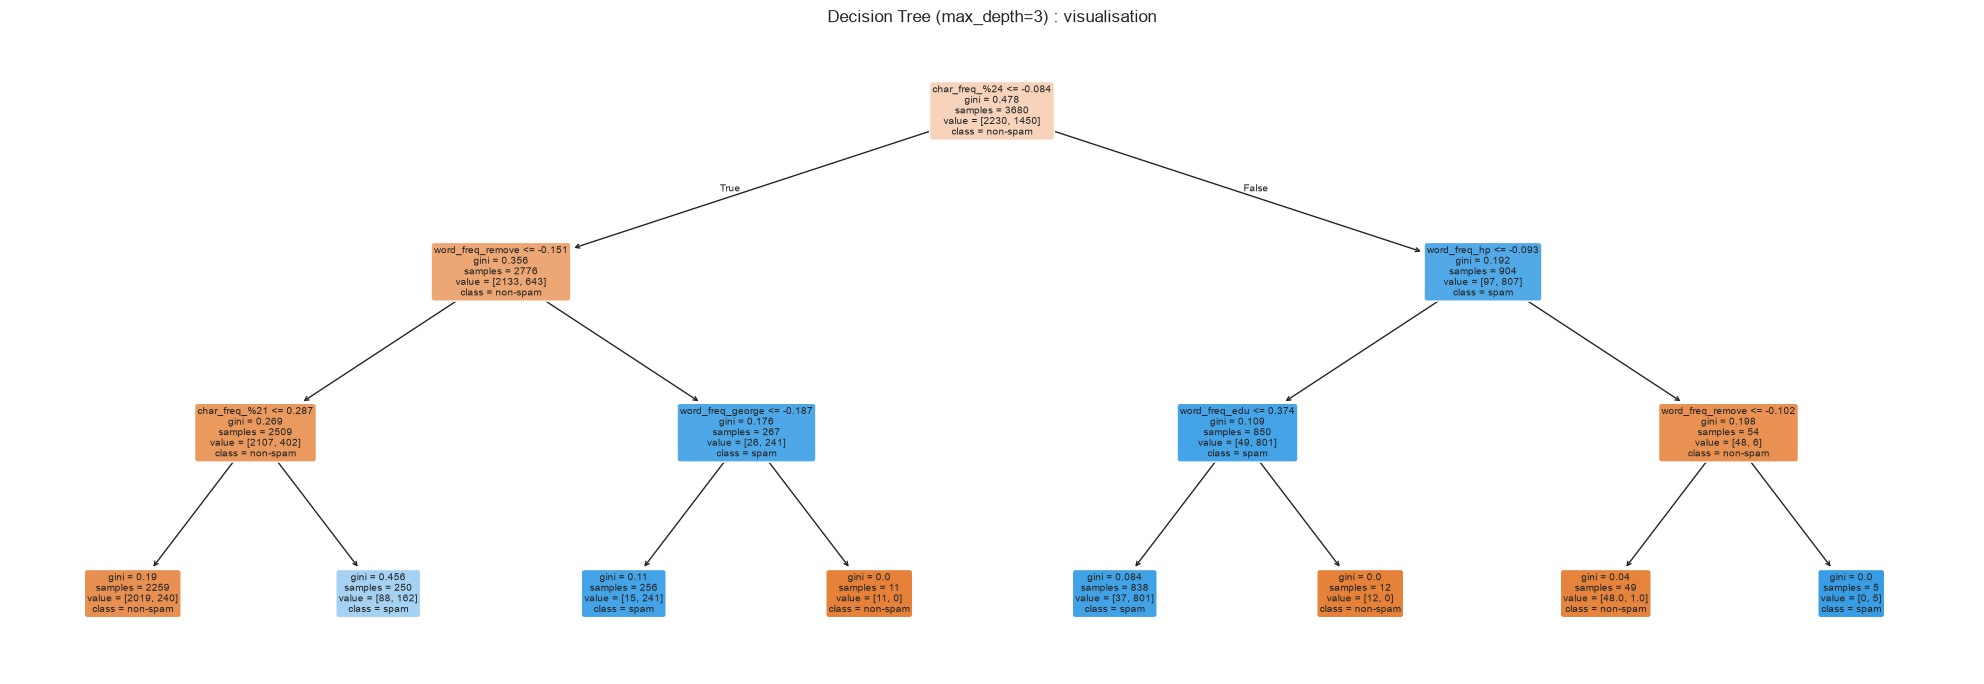

In [13]:
# Visualisation de l'arbre (profondeur 3 pour la lisibilité)
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_viz.fit(X_train_sc, y_train)

plt.figure(figsize=(20, 7))
plot_tree(dt_viz, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Decision Tree (max_depth=3) : visualisation')
plt.tight_layout()
plt.show()


---
## 6. Random Forest

Ensemble de **N arbres de décision** entraînés sur des sous-échantillons bootstrap et des sous-ensembles de features aléatoires.

In [14]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

# TODO : chercher les meilleurs hyperparametres avec GridSearchCV
# Indice : GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
rf = RandomForestClassifier(random_state=RANDOM_STATE)
gs_rf = GridSearchCV(rf, param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres RF : {gs_rf.best_params_}")
print(f"ROC-AUC CV             : {gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_


Meilleurs paramètres RF : {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
ROC-AUC CV             : 0.9867


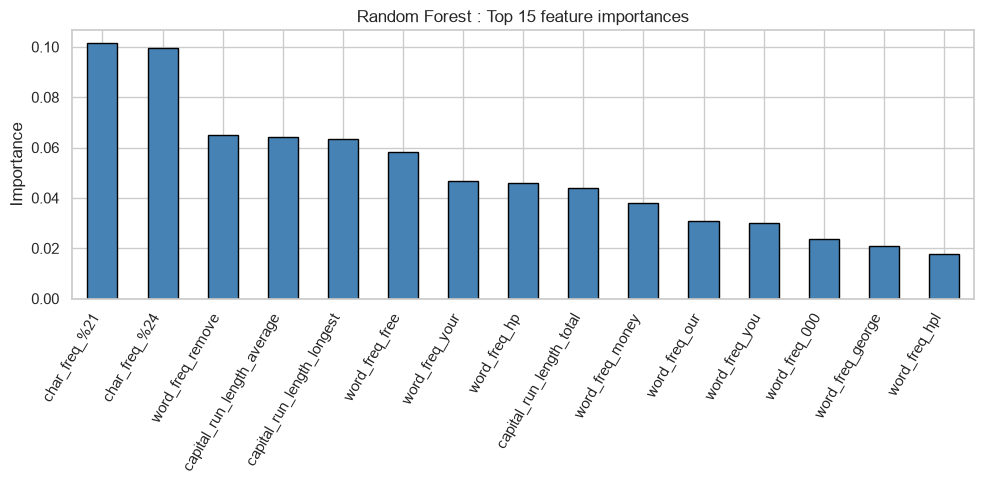

In [15]:
importances_rf = pd.Series(rf_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_rf.head(15).plot(kind='bar', color='steelblue', edgecolor='k')
plt.title('Random Forest : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 7. XGBoost

Boosting par gradient : construit les arbres **séquentiellement**, chaque arbre corrigeant les erreurs du précédent.

In [16]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
}

# TODO : chercher les meilleurs hyperparametres avec GridSearchCV
# Indice : GridSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0), param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
gs_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_xgb.fit(X_train_sc, y_train)

print(f"Meilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"ROC-AUC CV              : {gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_


Meilleurs paramètres XGB : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
ROC-AUC CV              : 0.9877


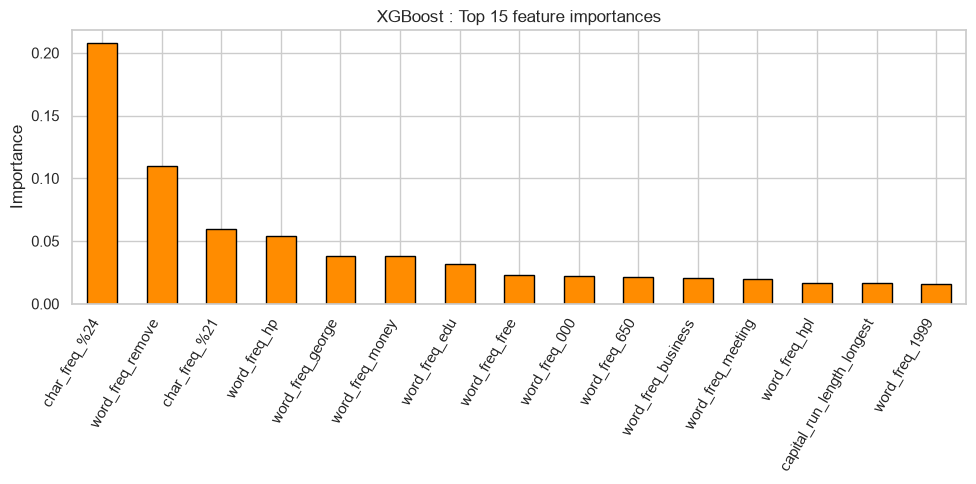

In [17]:
importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances_xgb.head(15).plot(kind='bar', color='darkorange', edgecolor='k')
plt.title('XGBoost : Top 15 feature importances')
plt.ylabel('Importance')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


---
## 8. Évaluation & comparaison

### 8.1 Métriques sur le jeu de test

In [18]:
models = {
    'Logistic Regression': pipe_lr,
    'KNN': pipe_knn,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

# Les modèles DT, RF, XGBoost ont été entraînés sur X_train_sc
# LR et KNN via pipeline (scaler inclus)
results = []
for name, model in models.items():
    # TODO : predire y_pred et y_proba sur le bon jeu de test (X_test pour LR/KNN, X_test_sc pour les autres)
    # puis calculer accuracy_score et roc_auc_score
    if name in ['Logistic Regression', 'KNN']:
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred = model.predict(X_test_sc)
        y_proba = model.predict_proba(X_test_sc)[:, 1]
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

df_results = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
df_results.round(4)


,Modèle,Accuracy,ROC-AUC
4,XGBoost,0.9468,0.9863
3,Random Forest,0.9501,0.9837
0,Logistic Regression,0.9262,0.9688
1,KNN,0.9034,0.9627
2,Decision Tree,0.9034,0.9266


### 8.2 Courbes ROC

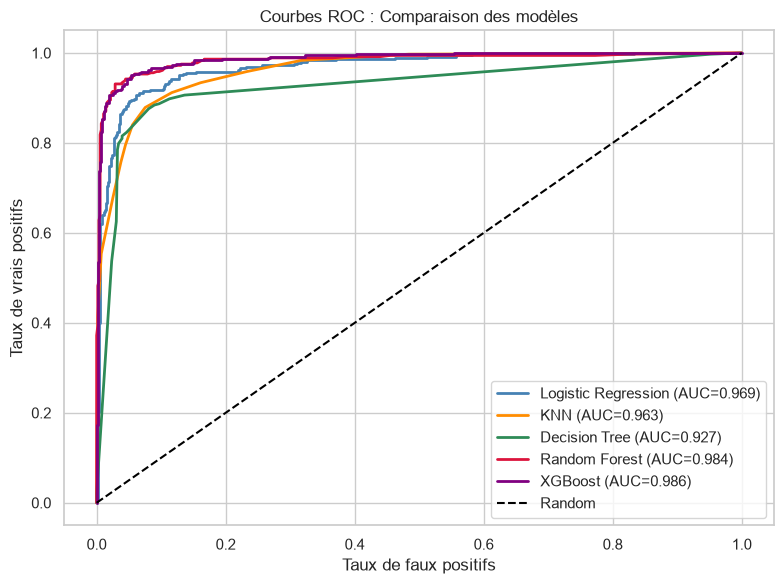

In [19]:
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']

plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), colors):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC : Comparaison des modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 8.3 Matrices de confusion

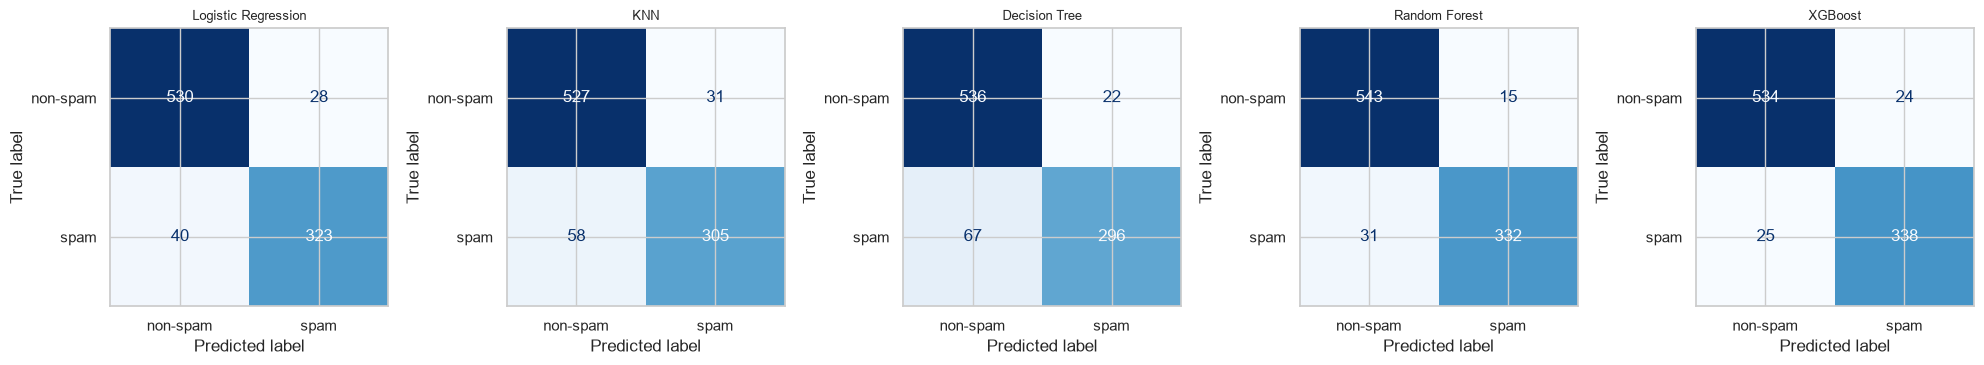

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    X_eval = X_test if name in ['Logistic Regression', 'KNN'] else X_test_sc
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

plt.tight_layout()
plt.show()


### 8.4 Rapport de classification du meilleur modèle

In [21]:
best_model_name = df_results.iloc[0]['Modèle']
best_model = models[best_model_name]
X_eval = X_test if best_model_name in ['Logistic Regression', 'KNN'] else X_test_sc

# TODO : afficher le rapport de classification complet (classification_report) du meilleur modele sur X_eval
print(f"Meilleur modèle : {best_model_name}\n")
print(classification_report(y_test, best_model.predict(X_eval)))

Meilleur modèle : XGBoost

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       558
           1       0.93      0.93      0.93       363

    accuracy                           0.95       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.95      0.95      0.95       921



---
## 9. Analyse de l'overfitting : courbes de validation

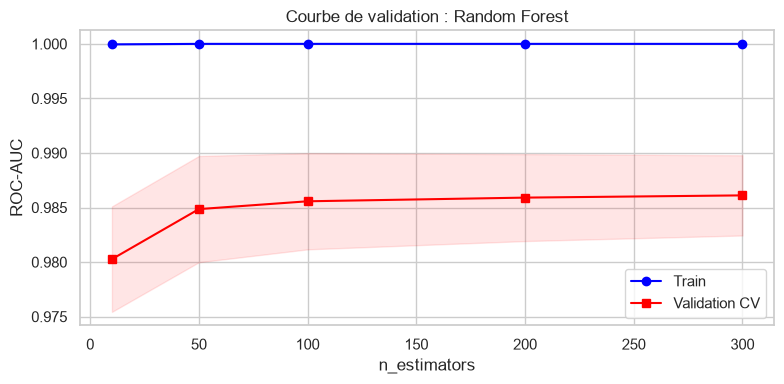

In [22]:
# Courbe de validation : RF : n_estimators
n_range = [10, 50, 100, 200, 300]
# TODO : calculer les scores train/validation pour chaque n_estimators avec validation_curve
# Indice : validation_curve(RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
#                            param_name='n_estimators', param_range=n_range, cv=cv, scoring='roc_auc', n_jobs=-1)
train_scores, val_scores = validation_curve(RandomForestClassifier(random_state=RANDOM_STATE), X_train_sc, y_train,
                                           param_name='n_estimators', param_range=n_range, cv=cv, scoring='roc_auc', n_jobs=-1)

plt.figure(figsize=(8, 4))
plt.plot(n_range, train_scores.mean(axis=1), 'b-o', label='Train')
plt.fill_between(n_range, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.1, color='b')
plt.plot(n_range, val_scores.mean(axis=1), 'r-s', label='Validation CV')
plt.fill_between(n_range, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='r')
plt.xlabel('n_estimators')
plt.ylabel('ROC-AUC')
plt.title('Courbe de validation : Random Forest')
plt.legend()
plt.tight_layout()
plt.show()


---
## 10. Explicabilité avec SHAP

Un modèle boîte noire (Random Forest, XGBoost) est précis mais difficile à justifier auprès du métier. Les **valeurs de Shapley** (SHAP) attribuent à chaque variable sa contribution à une prédiction, sans changer le modèle :
$$\text{prédiction} = \text{valeur de base} + \sum_{i} \text{valeur de Shapley}(x_i)$$

On illustre la méthode sur XGBoost.

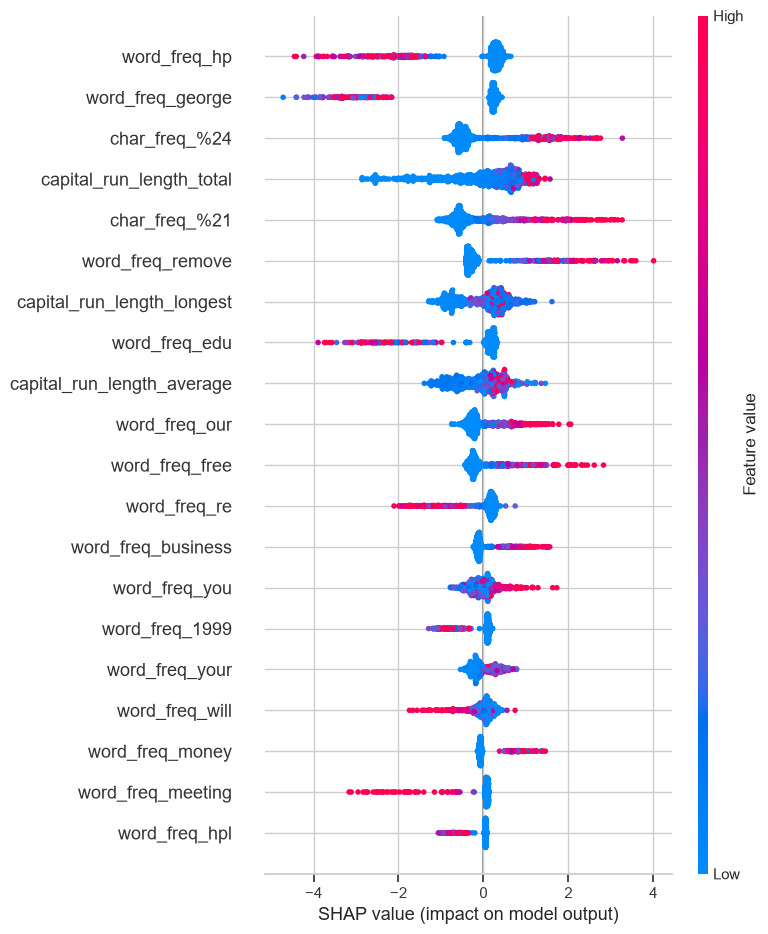

In [23]:
import shap

# TODO : creer un TreeExplainer sur xgb_best, puis calculer les shap_values sur X_test_sc
# Indice : explainer = shap.TreeExplainer(xgb_best) ; shap_values = explainer.shap_values(X_test_sc)
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_sc)

shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names)

**Lecture du graphique (summary plot) :** chaque point est un email du jeu de test. La position horizontale indique l'impact sur la prédiction (vers la droite : pousse vers "spam", vers la gauche : pousse vers "non-spam"), et la couleur la valeur de la feature (rouge = valeur élevée, bleu = valeur faible). Les variables sont triées par impact moyen absolu (importance globale).

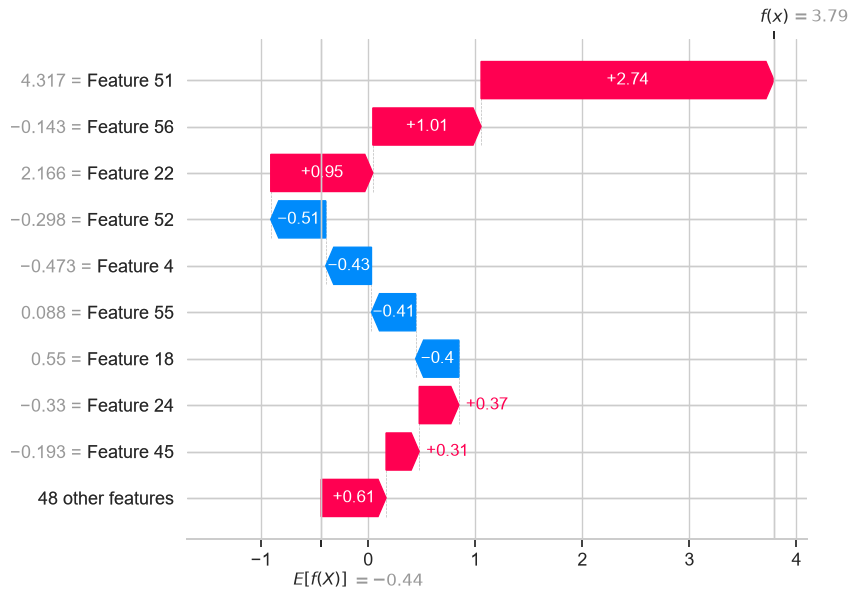

Vraie classe : spam | Prédite : spam


In [24]:
# TODO : expliquer la premiere observation du jeu de test et tracer un waterfall plot
# Indice : explanation = explainer(X_test_sc[:1]) ; shap.plots.waterfall(explanation[0])
explanation = explainer(X_test_sc[:1])
shap.plots.waterfall(explanation[0])
print(f"Vraie classe : {class_names[y_test[0]]} | Prédite : {class_names[xgb_best.predict(X_test_sc[:1])[0]]}")

---
## 11. Choisir le modèle final : erreur, performance et explicabilité

Le modèle final ne se choisit pas seulement sur la métrique de performance : trois critères entrent en jeu :
1. **Minimiser l'erreur** (ici : 1 - accuracy)
2. **Maximiser la performance** (ici : ROC-AUC, robuste au déséquilibre de classes)
3. **Maximiser l'explicabilité** (nativement interprétable, ou via SHAP pour une boîte noire)

In [25]:
explicabilite = {
    'Logistic Regression': 'Haute (coefficients directs)',
    'KNN': 'Faible (pas de règle ni de coefficient)',
    'Decision Tree': 'Très haute (règles lisibles)',
    'Random Forest': 'Moyenne (boîte noire, expliquée via SHAP)',
    'XGBoost': 'Moyenne (boîte noire, expliquée via SHAP)',
}

# TODO : construire df_choix a partir de df_results, avec une colonne 'Erreur (1 - Accuracy)'
# et une colonne 'Explicabilite' (via explicabilite.map sur la colonne 'Modèle')
df_choix = df_results.copy()
df_choix['Erreur (1 - Accuracy)'] = 1 - df_choix['Accuracy']
df_choix['Explicabilité'] = df_choix['Modèle'].map(explicabilite)
df_choix = df_choix[['Modèle', 'Erreur (1 - Accuracy)', 'ROC-AUC', 'Explicabilité']]
df_choix.round(4)

,Modèle,Erreur (1 - Accuracy),ROC-AUC,Explicabilité
4,XGBoost,0.0532,0.9863,"Moyenne (boîte noire, expliquée via SHAP)"
3,Random Forest,0.0499,0.9837,"Moyenne (boîte noire, expliquée via SHAP)"
0,Logistic Regression,0.0738,0.9688,Haute (coefficients directs)
1,KNN,0.0966,0.9627,Faible (pas de règle ni de coefficient)
2,Decision Tree,0.0966,0.9266,Très haute (règles lisibles)


In [26]:
# TODO : determiner le modele final (meilleure ligne de df_results par ROC-AUC, deja trie) et son modele associe
best_final_name = df_results.iloc[0]['Modèle']
best_final_model = models[best_final_name]

print(f"Modèle final retenu : {best_final_name}")
print(f"  Erreur (1 - Accuracy) : {1 - df_results.iloc[0]['Accuracy']:.4f}")
print(f"  ROC-AUC               : {df_results.iloc[0]['ROC-AUC']:.4f}")
print(f"  Explicabilité         : {explicabilite[best_final_name]}")

Modèle final retenu : XGBoost
  Erreur (1 - Accuracy) : 0.0532
  ROC-AUC               : 0.9863
  Explicabilité         : Moyenne (boîte noire, expliquée via SHAP)


---
## 12. Stocker le modèle final

In [27]:
import joblib
import os

os.makedirs('modeles', exist_ok=True)
# TODO : sauvegarder best_final_model avec joblib dans 'modeles/best_model_classification.pkl'
joblib.dump(best_final_model, 'modeles/best_model_classification.pkl')

print(f"Modèle sauvegardé : modeles/best_model_classification.pkl ({best_final_name})")

Modèle sauvegardé : modeles/best_model_classification.pkl (XGBoost)


Si `best_final_model` est un `Pipeline` scikit-learn (normalisation + modèle, comme pour Logistic Regression ou KNN dans ce TP), un seul fichier suffit. Si le modèle retenu a été entraîné sur des données déjà standardisées à la main (comme Decision Tree, Random Forest ou XGBoost ici, via `X_train_sc`), il faut aussi sauvegarder le `scaler` séparément (`joblib.dump(scaler, ...)`).

---
## 13. Inférence simple, sans API

In [28]:
# Nouvelles données à prédire (ici, un échantillon du jeu de test, pour l'exemple :
# en production ces lignes viendraient d'une nouvelle source, pas du jeu de test)
nouvelles_donnees = pd.DataFrame(X_test[:10], columns=feature_names)

# TODO : charger le modele sauvegarde, puis predire la classe et la probabilite de spam sur nouvelles_donnees
# Indice : si best_final_model est un Pipeline (LR/KNN), predict directement sur les donnees brutes
# sinon (arbre/foret/boosting), il faut d'abord standardiser avec scaler.transform
model_charge = joblib.load('modeles/best_model_classification.pkl')
predictions = model_charge.predict(nouvelles_donnees if best_final_name in ['Logistic Regression', 'KNN'] else scaler.transform(nouvelles_donnees))
probabilites = model_charge.predict_proba(nouvelles_donnees if best_final_name in ['Logistic Regression', 'KNN'] else scaler.transform(nouvelles_donnees))[:, 1]

nouvelles_donnees['prediction'] = [class_names[p] for p in predictions]
nouvelles_donnees['probabilite_spam'] = probabilites.round(4)
nouvelles_donnees.to_csv('predictions_classification.csv', index=False)

print(f"Prédictions sauvegardées : predictions_classification.csv ({len(nouvelles_donnees)} lignes)")
nouvelles_donnees[['prediction', 'probabilite_spam']]

Prédictions sauvegardées : predictions_classification.csv (10 lignes)


,prediction,probabilite_spam
0,spam,0.9779
1,spam,0.9994
2,non-spam,0.0046
3,spam,0.9667
4,non-spam,0.0033
5,non-spam,0.0009
6,non-spam,0.0115
7,spam,0.9470
8,non-spam,0.0019
9,spam,0.9924


---
## 14. Conclusion

| Critère | LogReg | KNN | Decision Tree | Random Forest | XGBoost |
|---|---|---|---|---|---|
| Interprétabilité | ★★★★ | ★★ | ★★★★★ | ★★ | ★★ |
| Performance typique | ★★★ | ★★★ | ★★★ | ★★★★ | ★★★★★ |
| Sensible à l'échelle | Oui | Oui | Non | Non | Non |
| Risque d'overfitting | Faible | Moyen | Élevé | Faible | Moyen (à régler) |

**À retenir :** sur un problème de détection de spam, le rappel (ne pas rater de spam) et la précision (ne pas bloquer un email légitime) ont un coût très différent : le choix du modèle final dépend du seuil de décision et du contexte métier.

---
## Session à rendre

Cette section est à compléter et à rendre à l'issue du TP. Réponds à chaque question dans la
cellule *Réponse* juste en dessous, à partir des résultats que **tu as toi-même obtenus** en
réalisant ce notebook (il n'y a pas de réponse générique valable pour tout le monde : les valeurs
numériques, choix d'hyperparamètres et graphiques dépendent de ton exécution).

**Q1.** Quel C as-tu retenu pour la régression logistique, et comment as-tu arbitré entre les valeurs testées ?

*Réponse :*

La valeur de C qui a été retenue est 10 car il a le ROC-AUC CV le plus élevé

**Q2.** Quel k as-tu choisi pour KNN, sur quel critère ?

*Réponse :*

La valeur de K qui a été retenue est 12 car il a le ROC-AUC CV le plus élevé

**Q3.** Quelle profondeur maximale as-tu retenue pour l'arbre de décision ? As-tu observé du surapprentissage (écart train/test) pour les profondeurs plus grandes ?

*Réponse :*

J'ai retenue la profondeur de 6 car il commencé à avoir des écarts trop importants entre l'accuracy durant l'apprentissage et le ROC-AUC CV

**Q4.** Quels hyperparamètres GridSearchCV a-t-il sélectionnés pour le Random Forest et pour XGBoost ?

*Réponse :*

- Meilleurs paramètres RF : {'max_depth': None, 'max_features': 'log2', 'n_estimators': 200}
- Meilleurs paramètres XGB : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

**Q5.** D'après ton tableau récapitulatif, quel modèle obtient les meilleures performances, et selon quelle métrique ? Pour un filtre anti-spam, pourquoi privilégier la précision ou le rappel selon le cas (coût d'un faux positif : un email légitime classé comme spam) ?

*Réponse :*

Celui qui a de meilleur performanace est le XGBoost. On privilégie la précision pour éviter que les mails importants soit classifié faussement en tant que spam

**Q6.** Que montre la courbe de validation_curve que tu as tracée : à partir de quel réglage le modèle commence-t-il à surapprendre ?

*Réponse :*

A partir de 50 n_estimators le modèle commence à stagner en terme de ratio ROC AUC sur n_estimators

**Q7.** Sur le summary plot SHAP de XGBoost, quelles sont les 2-3 variables qui ont le plus d'impact sur la détection de spam ?

*Réponse :*

Ce sont word_freq_hp, word_freq_george puis char_freq_%24

**Q8.** Quel modèle final as-tu obtenu après arbitrage erreur/performance/explicabilité (section 11) ? Est-ce le même que le "meilleur" modèle de la section 8 ? Pourquoi ?

*Réponse :*

Modèle final retenu : XGBoost car elle possède la performance la plus élevé.


**Q9.** Sur les 10 nouvelles prédictions sauvegardées dans `predictions_classification.csv`, combien sont classées comme spam ?

*Réponse :*

Il y en a 5